In [2]:
data_dir = "../data"

import os
N_THREADS = '1'
os.environ['OMP_NUM_THREADS'] = N_THREADS
os.environ['OPENBLAS_NUM_THREADS'] = N_THREADS
os.environ['MKL_NUM_THREADS'] = N_THREADS
os.environ['VECLIB_MAXIMUM_THREADS'] = N_THREADS
os.environ['NUMEXPR_NUM_THREADS'] = N_THREADS

import csv
import warnings
import pickle
from pathlib import Path
from collections import defaultdict, Counter
from itertools import islice, chain, count, product
from contextlib import nullcontext
from concurrent.futures import ProcessPoolExecutor

import torch
import torch.utils.data
import coba as cb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit
from parameterfree import COCOB
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

try:
    torch.set_num_threads(3)
    torch.set_num_interop_threads(3)
except RuntimeError:
    pass

c0 = "#444"
c1 = "#0072B2"
c2 = "#E69F00"
c3 = "#009E73"
c4 = "#56B4E9"
c5 = "#D55E00"
c6 = "#F0E442"
c7 = "#CC79A7"
c8 = "#000000"
c9 = "#332288"

torch.set_default_device('cpu')
plt.rc('font', **{'size': 20})


class my_pct:
    def __init__(self,pct=50,lo=None,hi=None):
        self._pct = pct
        self._hi  = hi
        self._lo  = lo
    def point(self, sample):
        return np.nanpercentile(sample,self._pct)
    def point_interval(self, sample):
        m = np.nanpercentile(sample,self._pct)
        l = np.nanpercentile(sample,self._lo) if self._lo else m
        h = np.nanpercentile(sample,self._hi) if self._hi else m
        return (np.nanpercentile(sample,self._pct),None)

class my_median (my_pct):
    def __init__(self):
        super().__init__(50)

In [3]:
class FeedForward(torch.nn.Sequential):
    """A Generic implementation of Feedforward Neural Network"""

    class SkipModule(torch.nn.Module):
        def __init__(self, layers):
            super().__init__()
            self.layers = layers
        def forward(self,X):
            return X + self.layers(X)

    class ForceOneModule(torch.nn.Module):
        def forward(self,X):
            return torch.ones(size=(X.shape[0],1)).float()

    class RandomProjectionModule(torch.nn.Module):
        def __init__(self,indim,outdim):
            super().__init__()
            from sklearn.random_projection import GaussianRandomProjection
            self.projection = GaussianRandomProjection(outdim)
            self.projection.fit([[1]*indim])

        def forward(self,X):
            return torch.tensor(self.projection.transform(X)).float()

    def make_layer(self,curr_dim,spec):
        if isinstance(spec,float):
            return torch.nn.Dropout(spec), curr_dim
        if curr_dim is None and isinstance(spec,int):
            return None, spec
        if isinstance(spec,int):
            return torch.nn.Linear(curr_dim,spec),spec
        if spec == 'r':
            return torch.nn.ReLU(),curr_dim
        if spec == 'l':
            return torch.nn.LayerNorm(curr_dim),curr_dim
        if spec == 'b':
            return torch.nn.BatchNorm1d(curr_dim), curr_dim
        if spec == 's':
            return torch.nn.Sigmoid(),curr_dim
        if spec == '1':
            return FeedForward.ForceOneModule(), 1
        if isinstance(spec,(list,tuple)):
            if spec[0] == 'rp':
                out_dim = int(curr_dim*(1-spec[1]))
                return FeedForward.RandomProjectionModule(curr_dim,out_dim),out_dim
            else:
                return FeedForward.SkipModule(FeedForward([curr_dim] + spec)), curr_dim
        raise Exception(f"Bad Layer: {spec}")

    def __init__(self, specs, rng=1):
        """Instantiate a Feedfoward network according to specifications.

        Args:
            specs: A sequence of layer specifications as follows:
                -1 -- replaced with the input feature width
                <int> -- a LinearLayer with output width equal to <int>
                [0,1] -- a Dropout layer with the given probability
                'l' -- a LayerNorm
                'b' -- a BatchNorm1d
                'r' -- a ReLU layer
                's' -- a Sigmoid layer
                [] -- a skip layer with the given specifications
        """

        torch.manual_seed(rng)
        layers,width = [],None
        for spec in specs:
            layer,width = self.make_layer(width,spec)
            if layer: layers.append(layer)
        super().__init__(*(layers or [torch.nn.Identity()]))
        self.params = {"specs": specs, "rng": rng }

class VWL:
    def __init__(self, args):
        self._args = args
        self.params = {'vwl_args':args}
        self.vws = []
        self.multilabel = None
        assert "logistic" in args
    
    def initialize(self, nx, ny):
        self.vws = [cb.VowpalMediator() for _ in range(ny)]
        if ny == 2: return
        for vw in self.vws: vw.init_learner(self._args, 1)
    def predict(self, features):
        if len(self.vws) ==2: return [.5,.5]
        return [ float(1/(1+np.exp(-vw.predict(vw.make_example({"x":features}))))) for vw in self.vws ] #type: ignore
    def learn(self, features, value, prob):
        if len(self.vws) == 2: return
        for vw,v in zip(self.vws,value):
            assert v in [0,1]
            vw.learn(vw.make_example({"x":features}, f"{v or -1} {1/prob}")) #type: ignore

class TL:
    def __init__(self, specs):
        self._network = None
        self._specs = specs
        self._loss = torch.nn.BCEWithLogitsLoss()
        self._sig = torch.nn.Sigmoid()
        self.params = {'specs': specs}

    def initialize(self,nx,ny):
        self._specs[0] = nx
        self._specs[-1] = ny
        self._network = FeedForward(self._specs)
        self._opt = COCOB(self._network.parameters())
        return self._network

    def __deepcopy__(self,memo):
        cloned = TL(self._specs)
        if self._network:
            from pathlib import Path
            from uuid import uuid4
            Path(".temp").mkdir(exist_ok=True)
            filename = f".temp/{uuid4()}"
            torch.save(self._network.state_dict(), filename)
            cloned._network = FeedForward(self._specs)
            cloned._network.load_state_dict(torch.load(filename, weights_only=True))            
            cloned._opt = COCOB(cloned._network.parameters())
            Path(filename).unlink()
        return cloned

    def predict(self, features):
        with torch.no_grad():
            return self._sig(self._network(torch.tensor(features))).tolist() #type: ignore

    def learn(self, features, value, prob):
        self._opt.zero_grad()
        ((1/prob)*self._loss(self._network(torch.tensor(features)),torch.tensor(value))).backward() #type: ignore
        self._opt.step()

In [ ]:
class MyEnvironment:
    def __init__(self, L, g, rng, n_concepts, n_subjects, n_examples, gnoise, mnoise):
        self.params = {'rng': rng, 'l':L, 'g':g }
        self.L = L
        self.g = g
        self.n_concepts = n_concepts
        self.n_subjects = n_subjects
        self.n_examples = n_examples
        self.gnoise     = gnoise
        self.mnoise     = mnoise
        self.rng        = rng

    def get_data(self):
        from sklearn.datasets import make_classification

        _X,_Y = make_classification(100)

        X,Y,G = None,None,None

        for i in range(self.n_concepts):
            _X0,_Y0 = make_classification(self.n_examples*self.n_subjects, random_state=self.rng+i)
            _X1,_Y1 = make_classification(self.n_examples*self.n_subjects, random_state=self.rng+100+i)

            _X0,_Y0 = torch.tensor(_X0).float(), torch.tensor(_Y0).unsqueeze(1).float()
            _X1,_Y1 = torch.tensor(_X1).float(), torch.tensor(_Y1).unsqueeze(1).float()

            _X0 = _X0 + torch.randn(_X0.shape) * self.gnoise
            _X1 = _X1 + torch.randn(_X1.shape) * self.gnoise

            _X0 = _X0 * (torch.rand(_X0.shape) > self.mnoise).float()
            _X1 = _X1 * (torch.rand(_X1.shape) > self.mnoise).float()

            _X = torch.hstack([_X0,_X1])
            _Y = torch.hstack([_Y0,_Y1])

            for j in range(self.n_subjects):
                __X = _X[j*self.n_examples:(j+1)*self.n_examples]
                __Y = _Y[j*self.n_examples:(j+1)*self.n_examples]
                __G = __G = torch.zeros(n_examples)+i*self.n_subjects+j
                
                if X is None:
                    X,Y,G = __X,__Y,__G
                else:
                    X,Y,G = torch.vstack([X,__X]), torch.vstack([Y,__Y]), torch.hstack([G,__G])
        return X,Y,G

class MyEvaluator:
    def __init__(self, s1, s2, s3, s4, dae_steps, dae_dropn, dae_sig, dae_bin, ssl_samps, ssl_negs, ssl_tau, ssl_v, sl_steps, sl_drop, ws_steps, pers_lrn_cnt, pers_mem_cnt, pers_mem_rpt, pers_mem_rcl, weighted, outer, inner, ntrain):

        self.s1  = s1  #dae
        self.s2  = s2  #ssl
        self.s3  = s3  #sl
        self.s4  = s4 

        self.dae_steps = dae_steps
        self.dae_dropn = dae_dropn
        self.dae_sig   = dae_sig
        self.dae_bin   = dae_bin

        self.ssl_samps = ssl_samps
        self.ssl_negs  = ssl_negs
        self.ssl_tau   = ssl_tau
        self.ssl_v     = ssl_v

        self.sl_steps = sl_steps
        self.sl_drop  = sl_drop
        self.ws_steps = ws_steps

        self.pers_lrn_cnt = pers_lrn_cnt
        self.pers_mem_cnt = pers_mem_cnt
        self.pers_mem_rpt = pers_mem_rpt
        self.pers_mem_rcl = pers_mem_rcl

        self.weighted = weighted

        self.learn  = (pers_lrn_cnt > 0)
        self.replay = (pers_lrn_cnt > 0) and (pers_mem_cnt > 0)

        self.outer = outer
        self.inner = inner

        self.ntrain = ntrain

        self.params = {'s1': s1, 's2': s2, 's3': s3, 's4':s4, 'dae': (dae_steps,dae_dropn,dae_sig,dae_bin), 'ssl': (ssl_samps,ssl_negs,ssl_tau,ssl_v), 'sl': (sl_steps,sl_drop), 'ws': (ws_steps), 'pers': (pers_lrn_cnt), 'exp':(pers_mem_cnt,pers_mem_rpt,pers_mem_rcl), 'test':(outer,inner), 'weighted': weighted }

    def evaluate(self, env, lrn):
        from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, precision_score, recall_score
        from collections import Counter

        import os
        N_THREADS = '1'
        os.environ['OMP_NUM_THREADS'] = N_THREADS
        os.environ['OPENBLAS_NUM_THREADS'] = N_THREADS
        os.environ['MKL_NUM_THREADS'] = N_THREADS
        os.environ['VECLIB_MAXIMUM_THREADS'] = N_THREADS
        os.environ['NUMEXPR_NUM_THREADS'] = N_THREADS

        X,Y,G = env.get_data()
        if len(X) == 0: return

        torch.set_num_threads(1)

        def make_weights(G):
            W = torch.zeros((len(G),1))
            weights = Counter(G.tolist())
            for g,w in weights.items():
                W[G==g] = 1/w
            return (W / W.max())

        def get_trn_tst(G,g):
            is_tst = sum(G == i for i in g).bool() #type: ignore
            return ~is_tst, is_tst

        def sslv1(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))

            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}

            for g in set(G):
                Xg[g] = list(compress(X,map(eq,G,repeat(g))))
                Yg[g] = list(compress(Y,map(eq,G,repeat(g))))

            eq_class  = {y: list(compress(X,map(eq,Y,repeat(y)))) for y in set(Y)}
            ne_class  = {y: list(compress(X,map(ne,Y,repeat(y)))) for y in set(Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(100,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(100,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            for i in range(nsamps):
                anchor, positive, negative = [], [], []
                for g in set(G):
                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[y],i))
                    negative.append(choose_n     (ne_class[y],nnegs))
                yield torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def sslv2(X,Y,G,nsamps,nnegs):
            from itertools import compress, repeat, chain
            from operator import eq, ne

            rng = cb.CobaRandom(1)
            rng_order = rng.shuffle(range(len(X)))

            X = X.tolist()
            Y = list(map(tuple,Y.tolist()))
            G = G.tolist()

            X = list(map(X.__getitem__,rng_order))
            Y = list(map(Y.__getitem__,rng_order))
            G = list(map(G.__getitem__,rng_order))

            Xg = {}
            Yg = {}
            eq_class = {}
            ne_class = {}

            for g in set(G):
                _X = list(compress(X,map(eq,G,repeat(g))))
                _Y = list(compress(Y,map(eq,G,repeat(g))))

                Xg[g] = _X
                Yg[g] = _Y

                eq_class[g] = {y: list(compress(_X,map(eq,_Y,repeat(y)))) for y in set(_Y)}
                ne_class[g] = {y: list(compress(_X,map(ne,_Y,repeat(y)))) for y in set(_Y)}

            def choose_unique(items,given_i):
                if len(items) == 1:  return items[0]
                for i in rng.randints(100,0,len(items)-1):
                    if i != given_i:
                        return items[i]

            def choose_n(items,n):
                add_to_index = (indexes := set()).add if len(items) > n else (indexes := []).append
                for i in rng.randints(100,0,len(items)-1):
                    add_to_index(i)
                    if len(indexes)==n:
                        return [items[i] for i in indexes]

            for i in range(nsamps):
                anchor, positive, negative = [], [], []
                for g in rng.shuffle(set(G)):
                    if len(set(Yg[g])) == 1: continue

                    x,y = Xg[g][i%len(Xg[g])],Yg[g][i%len(Yg[g])]
                    anchor.append(x)
                    positive.append(choose_unique(eq_class[g][y],i%len(Yg[g])))
                    negative.append(choose_n     (ne_class[g][y],nnegs))

                yield torch.tensor(anchor).float(), torch.tensor(positive).float(), torch.tensor(negative).float()

        def remove_na(X,Y,G=None):
            any_na = torch.isnan(Y)
            if Y.ndim==2: any_na = any_na.any(dim=1)
            if G == None: return X[~any_na],Y[~any_na]
            else: return X[~any_na],Y[~any_na],G[~any_na]

        def replace_x(layers,n_feats,n_persons):
            new_layers = []
            for l in layers:
                if l == 'x': 
                    new_layers.append(n_feats)
                elif isinstance(l,(tuple,list)):
                    new_layers.append(replace_x(l,n_feats,n_persons))
                else: 
                    new_layers.append(l)
            return new_layers

        def pretrain(trn_X,trn_Y,trn_G):
            n_feats = trn_X.shape[1]
            n_persons = len(set(trn_G.tolist()))
            n_tasks = trn_Y.shape[1]

            _s1 = replace_x(self.s1,n_feats,n_persons)
            _s2 = replace_x(self.s2,n_feats,n_persons)
            _s3 = replace_x(self.s3,n_feats,n_persons)
            _s4 = replace_x(self.s4,n_feats,n_persons)

            _s1 = [n_tasks if f == 'y' else f for f in _s1]
            _s2 = [n_tasks if f == 'y' else f for f in _s2]
            _s3 = [n_tasks if f == 'y' else f for f in _s3]

            _s3 = [n_persons*n_tasks if f == -1 else f for f in _s3]
            _s4 = [n_persons*n_tasks if f == -1 else f for f in _s4]

            s1 = FeedForward(_s1)
            s2 = FeedForward(_s2)
            s3 = FeedForward(_s3)
            s4 = FeedForward(_s4)

            s1_children = list(s1.children())
            s3_children = list(s3.children())

            sa = torch.nn.Sequential(*s1_children[len(s1_children)-self.dae_dropn:])
            s1 = torch.nn.Sequential(*s1_children[:len(s1_children)-self.dae_dropn])

            sb = torch.nn.Sequential(*s3_children[len(s3_children)-self.sl_drop:])
            s3 = torch.nn.Sequential(*s3_children[:len(s3_children)-self.sl_drop])

            s1opt = COCOB(s1.parameters()) if list(s1.parameters()) else None
            saopt = COCOB(sa.parameters()) if list(sa.parameters()) else None
            s2opt = COCOB(s2.parameters()) if list(s2.parameters()) else None
            s3opt = COCOB(s3.parameters()) if list(s3.parameters()) else None
            sbopt = COCOB(sb.parameters()) if list(sb.parameters()) else None

            mods = [s1,sa,s2,s3,sb]
            opts = [s1opt,saopt,s2opt,s3opt,sbopt]

            for m in mods: m.train()

            [s1,sa,s2,s3,sb] = mods
            [s1opt,saopt,s2opt,s3opt,sbopt] = opts

            if _s1 and self.dae_steps:
                opts = list(filter(None,[s1opt,saopt]))
                X,G,W = trn_X,trn_G,make_weights(trn_G)

                if _s1[-1] != n_feats*n_persons:
                    Z = X
                else:
                    i = defaultdict(lambda c= count(0):next(c))
                    I = torch.tensor([[i[g]] for g in G.tolist()]) * n_feats + torch.arange(n_feats).unsqueeze(0)
                    R = torch.arange(len(X)).unsqueeze(1)
                    Z = torch.full((len(X),len(i)*n_feats), float('nan'))
                    Z[R,I] = X

                torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                isb = ((X == 1) | (X == 0) | torch.isnan(X)).all(dim=0)
                isn = ~isb
                nn  = (isn).sum()

                loss = torch.nn.MSELoss()
                for _ in range(self.dae_steps):
                    for (_X,_z,_w) in torch_loader:
                        for o in opts: o.zero_grad()

                        rn = torch.randn(size=(_X.shape[0],nn)) * self.dae_sig
                        ri = torch.rand(size=_X.shape) < self.dae_bin

                        _X[isb&ri] = 1-_X[isb&ri]
                        _X[:,isn] += rn

                        loss(sa(s1(_X.nan_to_num()))[~_z.isnan()],_z[~_z.isnan()]).backward()
                        for o in opts: o.step()

            if self.ssl_samps:
                X, Y, G = trn_X,trn_Y,trn_G

                if self.ssl_negs == 0: raise Exception("neg can't be 0")
                if self.ssl_tau == 0: raise Exception("Tau can't be 0")

                ssl = sslv1 if self.ssl_v == 1 else sslv2

                for A,P,N in ssl(X, Y, G, self.ssl_samps, self.ssl_negs):
                    torch_dataset = torch.utils.data.TensorDataset(A,P,N)
                    torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=4,drop_last=False,shuffle=True)

                    for _A, _P, _N in torch_loader:
                        #https://arxiv.org/pdf/2002.05709
                        _A = s2(s1(_A.nan_to_num()))
                        _P = s2(s1(_P.nan_to_num()))
                        _N = s2(s1(_N.nan_to_num()))

                        p = torch.einsum("bi,bi->b",_A,_P)
                        n = torch.einsum("bi,bji->bj",_A,_N)

                        p /= (torch.linalg.norm(_A,dim=1)*torch.linalg.norm(_P,dim=1))
                        n /= (torch.linalg.norm(_A,dim=1).unsqueeze(1)*torch.linalg.norm(_N,dim=2))

                        p = torch.exp(p/self.ssl_tau)
                        n = torch.exp(n/self.ssl_tau)

                        if s2opt: s2opt.zero_grad()
                        (-torch.log(p/(p+n.sum(dim=1)))).mean().backward()
                        if s2opt: s2opt.step()

            if self.sl_steps:
                opts = list(filter(None,[s1opt,s2opt,s3opt,sbopt]))
                for o in opts: o.zero_grad()

                X, Y, G, W = trn_X,trn_Y,trn_G,make_weights(trn_G)

                if _s3[-1] != n_tasks*n_persons:
                    Z = Y
                else:
                    i = defaultdict(lambda c= count(0):next(c))
                    I = torch.tensor([[i[g]] for g in G.tolist()]) * n_tasks + torch.arange(n_tasks).unsqueeze(0)
                    R = torch.arange(len(Y)).unsqueeze(1)
                    Z = torch.full((len(G),len(i)*n_tasks), float('nan'))
                    Z[R,I] = Y

                torch_dataset = torch.utils.data.TensorDataset(X,Z,W)
                torch_loader  = torch.utils.data.DataLoader(torch_dataset,batch_size=8,drop_last=True,shuffle=True)

                for _ in range(self.sl_steps):
                    for _X,_z,_w in torch_loader:
                        for o in opts: o.zero_grad()
                        loss = torch.nn.BCEWithLogitsLoss(weight=_w.squeeze() if 2 in self.weighted else None)
                        loss(sb(s3(s2(s1(_X.nan_to_num()))))[~_z.isnan()],_z[~_z.isnan()]).backward()
                        for o in opts: o.step()

            for m in mods: m.eval()

            def pretrained(x):
                with torch.no_grad():
                    return s4(s3(s2(s1(x.nan_to_num()))))

            return pretrained

        def get_score(Y_true,Y_prob):
            out = dict()

            Y_pred = (np.array(Y_prob)>=.5).astype(float).tolist()
            Y_true = list(zip(*Y_true))
            Y_prob = list(zip(*Y_prob))
            Y_pred = list(zip(*Y_pred))

            for i,pred,true,prob in zip(count(),Y_pred,Y_true,Y_prob):

                one = len(set(true)) == 1

                tp = sum([p==1 and t==1 for p,t in zip(pred,true)])
                tn = sum([p==0 and t==0 for p,t in zip(pred,true)])
                fp = sum([p==1 and t==0 for p,t in zip(pred,true)])
                fn = sum([p==0 and t==1 for p,t in zip(pred,true)])

                out[f"auc{i}"] = float('nan') if one else roc_auc_score(true,prob)
                out[f"bal{i}"] = float('nan') if one else balanced_accuracy_score(true,pred)
                out[f"sen{i}"] = float('nan') if one else tp/(tp+fn)
                out[f"spe{i}"] = float('nan') if one else tn/(tn+fp)

                for j in [0,1]:
                    out[f"f1{j}{i}" ] = float('nan') if one else f1_score(true,pred,pos_label=j)
                    out[f"pre{j}{i}"] = float('nan') if one else precision_score(true,pred,pos_label=j,zero_division=0)
                    out[f"rec{j}{i}"] = float('nan') if one else recall_score(true,pred,pos_label=j)

                out[f"f1m{i}"] = float('nan') if one else f1_score(true,pred,average='macro')
                out[f"f1w{i}"] = float('nan') if one else f1_score(true,pred,average='weighted')

            return out

        def get_scores(X,Y,G,g):

            torch.manual_seed(env.params['rng'])
            rng = cb.CobaRandom(env.params['rng'])

            is_trn, is_tst = get_trn_tst(G,g)
            trn_X, trn_Y, trn_G = X[is_trn], Y[is_trn], G[is_trn]
            tst_X, tst_Y, tst_G = X[is_tst], Y[is_tst], G[is_tst]

            trn_X,trn_Y,trn_G = remove_na(trn_X,trn_Y,trn_G) #type:ignore
            tst_X,tst_Y,tst_G = remove_na(tst_X,tst_Y,tst_G) #type:ignore

            try:
                next(StratifiedShuffleSplit(1,train_size=self.ntrain).split(tst_X,tst_Y))
            except:
                return

            if len(tst_Y) < 25: return
            if len(set(map(tuple,tst_Y.tolist()))) == 1: return

            pretrained = pretrain(trn_X,trn_Y,trn_G)

            trn_X = pretrained(trn_X)
            tst_X = pretrained(tst_X)

            outer = self.outer
            inner = self.inner

            scores = [[] for _ in range(self.ntrain+1)]
            for k in range(outer):

                lrn_ = lrn

                lrn_.initialize(trn_X.shape[1], trn_Y.shape[1])

                for _ in range(int(np.ceil(self.ws_steps))):

                    rng_indexes = rng.shuffle(range(len(trn_X)))

                    if self.ws_steps < 1:
                        rng_indexes = rng_indexes[:int(len(rng_indexes)*self.ws_steps)]

                    X, Y = trn_X[rng_indexes], trn_Y[rng_indexes]

                    X, Y = X.tolist(), Y.tolist()

                    counts = Counter(map(tuple,Y))
                    denom = sum(counts.values())

                    for x,y in zip(X,Y):
                        lrn_.learn(x,y,counts[tuple(y)]/denom if 4 in self.weighted else 1)

                for j in range(inner):

                    lrn__ = lrn_

                    mems = []
                    bits = []

                    rng = cb.CobaRandom(seed=k*inner+j+env.params['rng'])
                    rng_indexes = rng.shuffle(range(len(tst_X)))
                    X, Y = tst_X[rng_indexes], tst_Y[rng_indexes]
                    X, Y = X.tolist(), Y.tolist()

                    trn,tst = next(StratifiedShuffleSplit(1,train_size=self.ntrain,random_state=j).split(X,Y))

                    for i in range(self.ntrain):

                        scores[i].append(get_score([Y[t] for t in tst],[lrn__.predict(X[t]) for t in tst]))
                        
                        x, y  = X[trn[i]], Y[trn[i]]
                        if self.learn : bits.append((x,y))
                        if self.replay: mems.append(((x,y),self.pers_mem_rpt))

                        if self.replay and len(mems) >= self.pers_mem_cnt and rng.random() < self.pers_mem_rcl:
                            rng.shuffle(mems, inplace=True)
                            for h in reversed(range(max(self.pers_mem_rcl,1))):
                                if h >= len(mems): continue
                                mem,n = mems[h]
                                x,y = mem
                                lrn__.learn(x,y,1)
                                if n == 1: mems.pop(h)
                                else: mems[h] = [mem,n-1]

                        if self.learn and len(bits) >= self.pers_lrn_cnt:
                            for x,y in bits[:self.pers_lrn_cnt]:
                                lrn__.learn(x,y,1)
                            del bits[:self.pers_lrn_cnt]

                    scores[self.ntrain].append(get_score([Y[t] for t in tst],[lrn__.predict(X[t]) for t in tst]))

            for s in scores:
                yield {k:np.nanmean([s_[k] for s_ in s]) for k in s[0].keys()}

        yield from get_scores(X,Y[:,env.L],G,env.g)

rng = cb.CobaRandom(1)

n_concepts = 5
n_subjects = 2
n_examples = 300

envs  = []
envs += [ MyEnvironment([0],[g],rng,n_concepts,n_subjects,n_examples,.5,.2) for g in range(n_concepts*n_subjects) for rng in range(1) ]
#envs += [ MyEnvironment([1],[g],rng,n_concepts,n_subjects,n_examples,.5,.2) for g in range(n_concepts*n_subjects) for rng in range(15) ]

lrn = VWL("--loss_function logistic --quiet --coin --interactions xx")

vals =[
    MyEvaluator((                  ), (              ), (                 ), (),   0, 0,  0, 0,   0, 0,  0, 0, 0, 0, 0, 1, 0, 0, 0, [], 1, 1, 60),
    MyEvaluator(('x',20,'l','r','x'), (              ), (                 ), (), 120, 1, .2, 0,   0, 0,  0, 0, 0, 0, 0, 1, 0, 0, 0, [], 1, 1, 60),
    MyEvaluator((                  ), ('x',20,'l','r'), (                 ), (),   0, 0,  0, 0, 160, 3, .2, 2, 0, 0, 0, 1, 0, 0, 0, [], 1, 1, 60),
    MyEvaluator((                  ), ('x',20,'l','r'), (                 ), (),   0, 0,  0, 0, 160, 3, .2, 1, 0, 0, 0, 1, 0, 0, 0, [], 1, 1, 60),
    MyEvaluator((                  ), (              ), ('x',20,'l','r', 1), (),   0, 0,  0, 0,   0, 0,  0, 0, 5, 1, 0, 1, 0, 0, 0, [], 1, 1, 60),
    MyEvaluator((                  ), (              ), ('x',20,'l','r',-1), (),   0, 0,  0, 0,   0, 0,  0, 0, 5, 1, 0, 1, 0, 0, 0, [], 1, 1, 60),
    MyEvaluator(('x',20,'l','r','x'), (              ), ( 20,20,'l','r',-1), (), 120, 1,  0, 0,   0, 0,  0, 0, 5, 1, 0, 1, 0, 0, 0, [], 1, 1, 60),
]

# A refactored and cleaned up hyperparameter search for response and interest prediction
# I used this to determine which hyperparameter configurations to explore more deeply
res = cb.Experiment(envs,[lrn],vals).run(processes=35,quiet=True) #type: ignore

l = ["evaluator_id","s1","s2","s3","s4","dae","ssl","sl","ws","pers","l"]
res.where(l=[(0,)]).plot_learners(y='auc0',l=l,p=['g','rng'])
#res.where(l=[(1,)]).plot_learners(y='auc0',l=l,p=['g','rng'],err=my_pct(50))

2025-09-19 13:58:33 -- pid-2220205 -- Unexpected exception:

  File "/home/mrucker/Projects/coba/coba/experiments/process.py", line 179, in filter
    yield ["T4", (env_id, lrn_id, val_id), list(SafeEvaluator(val).evaluate(env,lrn))]
  File "/tmp/ipykernel_2196747/1254058273.py", line 502, in evaluate
    <unknown code, this is likely due to the code being in a Jupyter cell>
  File "/tmp/ipykernel_2196747/1254058273.py", line 497, in get_scores
    <unknown code, this is likely due to the code being in a Jupyter cell>

  IndexError: list index out of range

2025-09-19 13:58:34 -- pid-2220247 -- Unexpected exception:

  File "/home/mrucker/Projects/coba/coba/experiments/process.py", line 179, in filter
    yield ["T4", (env_id, lrn_id, val_id), list(SafeEvaluator(val).evaluate(env,lrn))]
  File "/tmp/ipykernel_2196747/1254058273.py", line 502, in evaluate
    <unknown code, this is likely due to the code being in a Jupyter cell>
  File "/tmp/ipykernel_2196747/1254058273.py", line 497, i

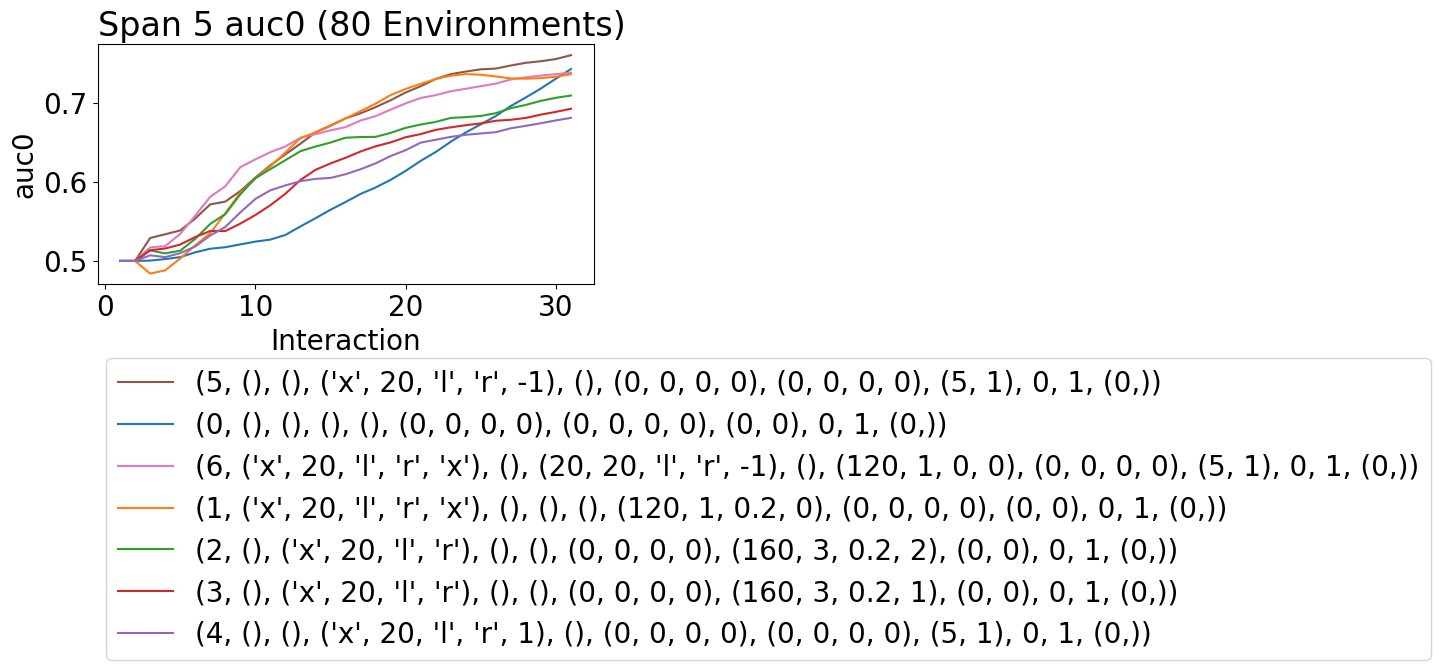

In [12]:
res.where(l=[(0,)]).plot_learners(y='auc0',l=l,p=['g','rng'],span=5)
